# Assignment 5 - Out-of-Sample Implementation Of Weekly Mean Reversion

## Purpose Of This Notebook

The companion idea-generation notebook identified a short-horizon cross-sectional mean-reversion effect in Swiss equities during the **2010-2019 development period**. Among the candidate definitions, it selected a volatility-scaled weekly reversal score.

This notebook evaluates that frozen score out of sample from **January 2020 onward**. The signal definition, weekly frequency, volatility lookback, tail fraction and timing convention are not re-selected using the evaluation period.

This notebook studies two implementations of the same frozen score:

1. A direct market-neutral long-short portfolio, which is the most transparent test of the ranking signal.
2. A constrained Black-Litterman long-only portfolio, which asks whether the same view can be incorporated into a benchmark-oriented and turnover-controlled strategy.

The analysis separates signal quality from implementation quality. Gross long-short results measure whether the ranking retains predictive value; assignment-compliant net returns, turnover, Black-Litterman results, SPI-relative statistics and multifactor regressions assess practical implementation.

## From Idea Generation To Portfolio Evaluation

The portfolio test inherits the following decisions from the idea-generation analysis:

| Design Component | Frozen Choice |
| --- | --- |
| Development period used for signal selection | January 2010 - December 2019 |
| Out-of-sample evaluation period | From January 2020 onward |
| Selected signal | Volatility-scaled weekly reversal |
| Return frequency | Weekly, Friday-labelled |
| Volatility lookback | 52 weeks, requiring at least 26 observations |
| Weekly signal lag | `0` |
| Long leg | Highest-scoring 30% of eligible securities |
| Short leg | Lowest-scoring 30% of eligible securities |
| Net exposure | Market-neutral: `+0.50` long and `-0.50` short |
| Rebalancing frequency | Weekly |

No alternative signal, tail fraction, volatility lookback or signal lag is selected in this notebook. The 2020+ period is used only to evaluate the already specified strategy.

## Frozen Volatility-Scaled Reversal Signal

Let $P_{i,d}$ be the closing price of stock $i$ on day $d$. Daily returns are

$$
r^D_{i,d}
=
\frac{P_{i,d}}{P_{i,d-1}} - 1.
$$

The strategy is formed at a weekly frequency by compounding daily returns within the Friday-labelled week $\mathcal{W}(t)$:

$$
R^W_{i,t}
=
\prod_{d \in \mathcal{W}(t)}(1+r^D_{i,d}) - 1.
$$

Trailing weekly volatility is estimated using up to one year of completed weekly returns:

$$
\sigma^W_{i,t}
=
Std\left(R^W_{i,t-51}, \ldots, R^W_{i,t}\right).
$$

The frozen score is

$$
s_{i,t}
=
-\frac{R^W_{i,t}}{\sigma^W_{i,t}}.
$$

A larger score corresponds to stronger recent underperformance after volatility scaling. Under the mean-reversion hypothesis, high-score securities are expected to rebound relative to low-score securities during the subsequent week:

$$
s_{i,t} \longrightarrow R^W_{i,t+1}.
$$

## Timing Convention

The score dated at the end of week $t$ uses only returns and trailing volatility observed through that completed week. The portfolio formed on that weekly rebalance date is then evaluated on subsequent returns.

Under the course backtesting framework's close-to-close convention, portfolio weights assigned on a rebalance date begin earning returns only after that date. The implementation therefore uses the contemporaneous completed-week score without an additional weekly delay:

```python
score_lag_weeks = 0
```

Applying a one-week shift would not merely address execution timing; it would change the researched hypothesis from immediate weekly reversal to a delayed reversal strategy.

## Imports And Project Paths

The implementation uses the professor-provided framework to construct portfolios, simulate realized returns and calculate turnover. The notebook adds only concise reporting logic around those framework results.

In [1]:
# ---------------------------------------------------------------------------
# Standard analysis libraries
# ---------------------------------------------------------------------------
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd

pd.options.display.float_format = "{:,.4f}".format


# Locate the repository whether execution begins at its root or in assignments/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir() or not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir() or not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Run this notebook from the repository root or assignments folder.")

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# ---------------------------------------------------------------------------
# Professor-provided backtesting framework
# ---------------------------------------------------------------------------
from helper_functions import load_data_spi
from estimation.covariance import Covariance
from backtesting.backtest import Backtest
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest_item_builder.bib_classes import OptimizationItemBuilder, SelectionItemBuilder
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_box_constraints,
    bibfn_budget_constraint,
    bibfn_size_dependent_upper_bounds,
    bibfn_turnover_constraint,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_cap_weights,
    bibfn_return_series,
    bibfn_scores,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_jkp_data_scores,
    bibfn_selection_min_volume,
)
from optimization.optimization import BlackLitterman, PercentilePortfolio


## Backtest Configuration

The configuration below records only assumptions required for the direct long-short test. Parameters defining the alpha signal and portfolio tails are frozen from the idea-generation notebook; transaction costs are varied only to measure implementation capacity.

In [2]:
@dataclass(frozen=True)
class StrategyConfig:
    # -----------------------------------------------------------------------
    # Out-of-sample evaluation period
    # -----------------------------------------------------------------------
    # Signal selection occurred in 2010-2019. Performance is reported only
    # from January 2020 onward.
    start_date: str = "2020-01-01"
    end_date: Optional[str] = None

    # -----------------------------------------------------------------------
    # Frozen signal construction
    # -----------------------------------------------------------------------
    # The weekly reversal score is inherited from the idea-generation notebook.
    weekly_resample_rule: str = "W-FRI"
    weekly_min_days: int = 3
    vol_lookback_weeks: int = 52
    min_vol_weeks: int = 26
    score_lag_weeks: int = 0

    # -----------------------------------------------------------------------
    # Frozen direct long-short portfolio rule
    # -----------------------------------------------------------------------
    # The top 30% of scores form the long rebound basket; the bottom 30%
    # form the basket whose return is subtracted in the combined portfolio.
    leg_fraction: float = 0.30
    long_weight: float = 0.50
    short_weight: float = -0.50

    # -----------------------------------------------------------------------
    # Transaction-cost capacity analysis
    # -----------------------------------------------------------------------
    # One-way costs are charged per unit of framework-generated turnover.
    transaction_cost_bps: tuple[int, ...] = tuple(range(0, 21, 2))
    required_transaction_cost_bps: int = 20
    required_fixed_cost_annual: float = 0.01

    # -----------------------------------------------------------------------
    # Tradability filters used by the course framework
    # -----------------------------------------------------------------------
    # The `liquidity` input is daily traded value. A CHF 200,000 trailing
    # median requirement retains a broad mid/large-cap tradable universe.
    min_median_daily_traded_value: float = 200_000
    volume_window_days: int = 365
    max_zero_volume_gap_days: int = 10
    lookback_days: int = 365 * 3

    # -----------------------------------------------------------------------
    # Black-Litterman constrained implementation
    # -----------------------------------------------------------------------
    # A relatively uncertain market-cap prior and confident relative view let
    # the previously selected reversal signal materially affect allocations.
    tau_psi: float = 0.05
    tau_omega: float = 0.0001
    view_gen_algo: str = "longshort_sort"
    stock_upper_bound: float = 0.10
    # The weekly signal needs flexibility, but turnover must be controlled.
    turnover_limit: float = 0.50
    solver_name: str = "cvxopt"

    # -----------------------------------------------------------------------
    # Reporting and storage
    # -----------------------------------------------------------------------
    trading_days_per_year: int = 252
    rebalances_per_year: int = 52
    data_dir: Path = DATA_DIR
    results_dir: Path = RESULTS_DIR
    score_path: Path = RESULTS_DIR / "mean_reversion_vol_scaled_scores_oos.parquet"


CONFIG = StrategyConfig()

# PercentilePortfolio retains scores above or below the stated percentile.
# A 30% tail therefore corresponds to the 70th and 30th percentile cutoffs.
TOP_PERCENTILE = int(100 * (1 - CONFIG.leg_fraction))      # Top 30% long: 70.
BOTTOM_PERCENTILE = int(100 * CONFIG.leg_fraction)         # Bottom 30% short: 30.

CONFIG


StrategyConfig(start_date='2020-01-01', end_date=None, weekly_resample_rule='W-FRI', weekly_min_days=3, vol_lookback_weeks=52, min_vol_weeks=26, score_lag_weeks=0, leg_fraction=0.3, long_weight=0.5, short_weight=-0.5, transaction_cost_bps=(0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20), required_transaction_cost_bps=20, required_fixed_cost_annual=0.01, min_median_daily_traded_value=200000, volume_window_days=365, max_zero_volume_gap_days=10, lookback_days=1095, tau_psi=0.05, tau_omega=0.0001, view_gen_algo='longshort_sort', stock_upper_bound=0.1, turnover_limit=0.5, solver_name='cvxopt', trading_days_per_year=252, rebalances_per_year=52, data_dir=WindowsPath('C:/Users/axeli/Desktop/Coding/GitHub/University/QPM/qpmwp-course/data'), results_dir=WindowsPath('C:/Users/axeli/Desktop/Coding/GitHub/University/QPM/qpmwp-course/results'), score_path=WindowsPath('C:/Users/axeli/Desktop/Coding/GitHub/University/QPM/qpmwp-course/results/mean_reversion_vol_scaled_scores_oos.parquet'))

## Market Data And Investable Universe

The strategy requires a valid stock identifier, price history and liquidity information for each security. Observations without a security identifier cannot be ranked or held and are removed before portfolio construction. Duplicate security-date records are resolved by retaining the final available observation.

The course demonstration uses a conservative CHF 500,000 median daily traded-value threshold. This implementation uses a moderate **CHF 200,000** threshold instead. The objective is not to remove tradability controls, but to avoid mechanically excluding a substantial portion of the mid-cap universe in which short-horizon reversal may occur. Together with the unchanged inactivity-gap screen, the strategy remains restricted to securities with meaningful recorded trading activity.

Data before 2020 remain available only to initialize trailing volatility estimates and the framework's historical tradability filters. Reported portfolio performance begins in 2020.

In [3]:
# ---------------------------------------------------------------------------
# Load and clean the stock-level market panel
# ---------------------------------------------------------------------------
market_data_raw = pd.read_parquet(CONFIG.data_dir / "market_data.parquet").copy()
date_level = market_data_raw.index.names.index("date")
market_data_raw.index = market_data_raw.index.set_levels(
    pd.to_datetime(market_data_raw.index.levels[date_level]),
    level=date_level,
)

# Missing identifiers cannot be linked to a security score or portfolio holding.
missing_id = market_data_raw.index.get_level_values("id").isna()
missing_id_rows = int(missing_id.sum())
identified_market_data = market_data_raw[~missing_id]

# Retain one auditable security-date record if duplicate observations occur.
duplicate_rows = int(identified_market_data.index.duplicated(keep="last").sum())
market_data = identified_market_data[
    ~identified_market_data.index.duplicated(keep="last")
].sort_index()

market_data_summary = pd.DataFrame(
    {
        "Dataset first date": [market_data.index.get_level_values("date").min()],
        "Dataset last date": [market_data.index.get_level_values("date").max()],
        "Unique securities": [market_data.index.get_level_values("id").nunique()],
        "Rows without identifier removed": [missing_id_rows],
        "Duplicate rows removed": [duplicate_rows],
        "Out-of-sample evaluation start": [pd.Timestamp(CONFIG.start_date)],
    },
    index=["Swiss equity market panel"],
)

market_data_summary


,Dataset first date,Dataset last date,Unique securities,Rows without identifier removed,Duplicate rows removed,Out-of-sample evaluation start
Swiss equity market panel,1985-12-31,2024-04-30,313,43449,0,2020-01-01


## Construction Of The Frozen Score

Only the selected volatility-scaled reversal score is constructed in this notebook. Alternative signal definitions were compared in the idea-generation notebook and are not revisited out of sample.

Weekly scores may be computed before 2020 because the rolling volatility estimator requires historical observations. However, those earlier score dates are used only as warm-up history and are excluded from reported portfolio performance.

In [4]:
# ---------------------------------------------------------------------------
# Daily and weekly return construction
# ---------------------------------------------------------------------------
prices = market_data["price"].unstack("id").sort_index()
daily_returns = prices.pct_change(fill_method=None)
weekly_returns = (
    (1 + daily_returns)
    .resample(CONFIG.weekly_resample_rule)
    .prod(min_count=CONFIG.weekly_min_days)
    - 1
)

# ---------------------------------------------------------------------------
# Trailing weekly volatility available at each formation date
# ---------------------------------------------------------------------------
weekly_volatility = weekly_returns.rolling(
    CONFIG.vol_lookback_weeks,
    min_periods=CONFIG.min_vol_weeks,
).std()

# ---------------------------------------------------------------------------
# Frozen volatility-scaled reversal score: no additional weekly lag
# ---------------------------------------------------------------------------
# High scores identify recent volatility-adjusted losers. The score at week t
# is used at that rebalance date under the course-framework timing convention.
vol_scaled_reversal = (-weekly_returns / weekly_volatility).replace(
    [np.inf, -np.inf], np.nan
)

# Map Friday-labelled weekly scores to actual trading dates, accommodating
# exchange holidays without moving any signal into the future.
trading_dates = pd.DatetimeIndex(prices.index).sort_values()
signal_to_rebalance_date = {}
for signal_date in pd.DatetimeIndex(vol_scaled_reversal.index).sort_values():
    eligible_dates = trading_dates[trading_dates <= signal_date]
    if len(eligible_dates) > 0:
        signal_to_rebalance_date[signal_date] = eligible_dates[-1]

# Store the score panel in the date-id format consumed by the framework's
# score-availability selection filter and PercentilePortfolio optimization.
score_panel = vol_scaled_reversal.stack().rename("vol_scaled_reversal").to_frame().reset_index()
score_panel["date"] = score_panel["date"].map(signal_to_rebalance_date)
score_panel = score_panel.dropna(subset=["date", "vol_scaled_reversal"])
score_panel["date"] = pd.to_datetime(score_panel["date"])
score_panel = score_panel.groupby(["date", "id"], as_index=True).last().sort_index()
score_panel.to_parquet(CONFIG.score_path)

# Performance dates begin in 2020 even though earlier scores are retained for
# estimation continuity and framework input compatibility.
oos_score_panel = score_panel.loc[
    score_panel.index.get_level_values("date") >= pd.Timestamp(CONFIG.start_date)
]
oos_counts = oos_score_panel.groupby(level="date")["vol_scaled_reversal"].count()
score_summary = pd.DataFrame(
    {
        "First eligible rebalance date": [oos_counts.index.min()],
        "Last eligible rebalance date": [oos_counts.index.max()],
        "Number of score dates": [len(oos_counts)],
        "Average securities with score": [oos_counts.mean()],
        "Median securities with score": [oos_counts.median()],
        "Implemented weekly lag": [CONFIG.score_lag_weeks],
    },
    index=["Out-of-sample score panel"],
)

score_summary


,First eligible rebalance date,Last eligible rebalance date,Number of score dates,Average securities with score,Median securities with score,Implemented weekly lag
Out-of-sample score panel,2020-01-03,2024-04-26,226,179.3230,180.0000,0


## Backtesting Framework And Tradability Filters

Portfolio formation uses the professor-provided framework. At each weekly rebalance date, the framework first identifies tradable securities and then passes the frozen reversal scores to an equal-weight percentile portfolio constructor.

The same tradability filters are applied to both baskets:

- a historical gap screen based on trading activity;
- a minimum-volume screen;
- availability of the frozen reversal score on or before the rebalance date.

This ensures that the two legs differ by their signal ranking, not by their investability rules.

In [5]:
# ---------------------------------------------------------------------------
# Framework data container and out-of-sample weekly rebalance calendar
# ---------------------------------------------------------------------------
data = BacktestData()
data.market_data = market_data
data.jkp_data = score_panel
spi = load_data_spi(path=CONFIG.data_dir).sort_index().rename("SPI")
data.bm_series = spi

# Earlier score history remains in `data`, but portfolios are formed only from
# the configured out-of-sample start date onward.
rebalance_source_dates = pd.DatetimeIndex(
    oos_score_panel.index.get_level_values("date").unique()
).sort_values()
if CONFIG.end_date is not None:
    rebalance_source_dates = rebalance_source_dates[
        rebalance_source_dates <= pd.Timestamp(CONFIG.end_date)
    ]

rebalance_dates = rebalance_source_dates.strftime("%Y-%m-%d").tolist()
# A final formation date without a subsequent holding interval cannot produce
# a complete strategy-return observation in the course simulator.
if len(rebalance_dates) > 1:
    rebalance_dates = rebalance_dates[:-1]
if not rebalance_dates:
    raise ValueError("No out-of-sample rebalance dates are available.")

# ---------------------------------------------------------------------------
# Common tradability filters: identical selection rules for both legs
# ---------------------------------------------------------------------------
selection_builders = {
    "gaps": SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=CONFIG.lookback_days,
        n_days=CONFIG.max_zero_volume_gap_days,
    ),
    "min_volume": SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=CONFIG.volume_window_days,
        min_volume=CONFIG.min_median_daily_traded_value,
        agg_fn=np.median,
    ),
    "jkp_data_scores": SelectionItemBuilder(
        bibfn=bibfn_selection_jkp_data_scores,
        fields=["vol_scaled_reversal"],
    ),
}

# PercentilePortfolio requires the selected score vector; framework return
# history is also supplied for consistent strategy construction and turnover.
score_optimization_builders = {
    "return_series": OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=CONFIG.lookback_days,
        weekdays_only=True,
        fillna_value=0,
    ),
    "scores": OptimizationItemBuilder(
        bibfn=bibfn_scores,
        fields=["vol_scaled_reversal"],
    ),
}

pd.DataFrame(
    {
        "Number of rebalances": [len(rebalance_dates)],
        "First rebalance date": [rebalance_dates[0]],
        "Last rebalance date": [rebalance_dates[-1]],
        "Score field": ["vol_scaled_reversal"],
        "Weekly signal lag": [CONFIG.score_lag_weeks],
    },
    index=["Course-framework evaluation calendar"],
)


,Number of rebalances,First rebalance date,Last rebalance date,Score field,Weekly signal lag
Course-framework evaluation calendar,225,2020-01-03,2024-04-19,vol_scaled_reversal,0


## Direct Long-Short Portfolio

The direct portfolio preserves the interpretation of the researched cross-sectional signal. At each rebalance date:

- the long basket contains the highest-scoring 30% of tradable securities, representing recent volatility-adjusted losers expected to rebound;
- the short basket contains the lowest-scoring 30%, representing recent volatility-adjusted winners;
- the professor framework assigns equal weights within each basket.

Each basket is simulated separately through the course framework. Their returns are combined into a market-neutral spread:

$$
R^{LS,gross}_{t}
=
0.50R^{Long}_{t}
-
0.50R^{ShortBasket}_{t}.
$$

The corresponding strategy turnover is exposure-scaled:

$$
Turnover^{LS}_{t}
=
0.50Turnover^{Long}_{t}
+
0.50Turnover^{ShortBasket}_{t}.
$$

This construction preserves the course-framework formation of each leg while producing the economically intended long-short reversal portfolio.

In [6]:
# ---------------------------------------------------------------------------
# Equal-weight ranked baskets constructed by the professor framework
# ---------------------------------------------------------------------------
long_leg = PercentilePortfolio(
    field="vol_scaled_reversal",
    percentile=TOP_PERCENTILE,       # 70th-percentile threshold: top 30%.
    sign=">=",
)

short_basket = PercentilePortfolio(
    field="vol_scaled_reversal",
    percentile=BOTTOM_PERCENTILE,    # 30th-percentile threshold: bottom 30%.
    sign="<=",
)

# The same data, rebalance calendar and tradability rules feed both baskets.
bs_long = BacktestService(
    data=data,
    selection_item_builders=selection_builders,
    optimization_item_builders=score_optimization_builders,
    optimization=long_leg,
    rebdates=rebalance_dates,
    quiet=False,
)

bs_short = BacktestService(
    data=data,
    selection_item_builders=selection_builders,
    optimization_item_builders=score_optimization_builders,
    optimization=short_basket,
    rebdates=rebalance_dates,
    quiet=False,
)


### Run Framework Portfolio Formation

The following two cells deliberately execute each leg through the professor framework before the returns are combined. This retains the framework's selection, portfolio-storage and turnover mechanics for both sides of the long-short strategy.

In [7]:
# Build weekly portfolios for recent volatility-adjusted losers (long basket).
bt_long = Backtest()
bt_long.run(bs_long)


Running backtest: 100%|##########| 225/225 [06:20<00:00,  1.69s/it, 2024-04-19]


In [8]:
# Build weekly portfolios for recent volatility-adjusted winners; the realized
# return of this basket is subtracted in the combined long-short strategy.
bt_short = Backtest()
bt_short.run(bs_short)


Running backtest: 100%|##########| 225/225 [06:29<00:00,  1.73s/it, 2024-04-19]


## Gross Out-Of-Sample Strategy Returns

The first evaluation reports performance before trading frictions. Gross results isolate whether the frozen ranking rule continues to contain economic information after 2019.

Returns and turnover are not reconstructed through an independent backtest. They are obtained from the portfolios generated by the course framework:

- `Strategy.simulate(...)` produces realized returns after each rebalance;
- `Strategy.turnover(...)` measures trading required to move between framework-generated portfolios.

In [9]:
# ---------------------------------------------------------------------------
# Framework-generated leg returns and turnover
# ---------------------------------------------------------------------------
return_series = data.get_return_series(weekdays_only=True, fillna_value=0)
return_series = return_series.loc[return_series.index >= pd.Timestamp(CONFIG.start_date)]
if CONFIG.end_date is not None:
    return_series = return_series.loc[return_series.index <= pd.Timestamp(CONFIG.end_date)]

long_leg_returns_gross = bt_long.strategy.simulate(
    return_series=return_series,
    fc=0.0,
    vc=0.0,
).rename("Long Leg Gross")
short_basket_returns_gross = bt_short.strategy.simulate(
    return_series=return_series,
    fc=0.0,
    vc=0.0,
).rename("Short Basket Gross")

long_turnover = bt_long.strategy.turnover(return_series=return_series, rescale=False)
short_turnover = bt_short.strategy.turnover(return_series=return_series, rescale=False)
long_turnover.index = pd.to_datetime(long_turnover.index)
short_turnover.index = pd.to_datetime(short_turnover.index)

# ---------------------------------------------------------------------------
# Market-neutral combination of the two framework-generated baskets
# ---------------------------------------------------------------------------
leg_returns = pd.concat([long_leg_returns_gross, short_basket_returns_gross], axis=1).dropna()
ls_gross_returns = (
    CONFIG.long_weight * leg_returns["Long Leg Gross"]
    + CONFIG.short_weight * leg_returns["Short Basket Gross"]
).rename("Long-Short Gross")
ls_combined_turnover = (
    abs(CONFIG.long_weight) * long_turnover
    + abs(CONFIG.short_weight) * short_turnover
).rename("Long-Short Turnover")

pd.concat([leg_returns, ls_gross_returns], axis=1).head()


,Long Leg Gross,Short Basket Gross,Long-Short Gross
date,,,
2020-01-06,-0.0044,-0.0082,0.0019
2020-01-07,0.0172,0.0056,0.0058
2020-01-08,-0.0037,0.0001,-0.0019
2020-01-09,-0.0031,0.0011,-0.0021
2020-01-10,-0.0063,-0.0004,-0.0030


## Performance Measures

Performance is reported from daily returns produced by the course simulator. Let $N$ be the number of daily return observations.

$$
R_{ann}=(1+R_{cum})^{252/N}-1,
\qquad
\sigma_{ann}=\sigma_d\sqrt{252},
\qquad
SR=\frac{\overline{R}_d}{\sigma_d}\sqrt{252}.
$$

Maximum drawdown measures the worst decline from a previous wealth peak. Turnover is reported because it is the mechanism through which a weekly reversal strategy incurs transaction costs.

In [10]:
# ---------------------------------------------------------------------------
# Minimal reporting helpers applied to framework-generated strategy series
# ---------------------------------------------------------------------------
def max_drawdown(returns: pd.Series) -> float:
    """Return the worst peak-to-trough loss of a cumulative wealth path."""
    wealth = (1 + returns.dropna()).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def performance_table(
    returns: pd.DataFrame,
    turnover_map: Optional[dict[str, pd.Series]] = None,
) -> pd.DataFrame:
    """Summarize daily simulated portfolio returns in annualized terms."""
    turnover_map = {} if turnover_map is None else turnover_map
    rows = []
    for name in returns.columns:
        series = returns[name].dropna()
        turnover = turnover_map.get(name)
        rows.append(
            {
                "Portfolio": name,
                "Annualized return": (1 + series).prod() ** (CONFIG.trading_days_per_year / len(series)) - 1,
                "Annualized volatility": series.std() * np.sqrt(CONFIG.trading_days_per_year),
                "Sharpe ratio": series.mean() / series.std() * np.sqrt(CONFIG.trading_days_per_year),
                "Maximum drawdown": max_drawdown(series),
                "Final cumulative return": (1 + series).prod() - 1,
                "Positive-return-day ratio": (series > 0).mean(),
                "Average weekly turnover": turnover.mean() if turnover is not None else np.nan,
                "Annualized turnover": turnover.mean() * CONFIG.rebalances_per_year if turnover is not None else np.nan,
                "Return observations": len(series),
            }
        )
    return pd.DataFrame(rows).set_index("Portfolio")


def subtract_rebalance_costs(
    gross_returns: pd.Series,
    turnover: pd.Series,
    transaction_cost: float,
) -> pd.Series:
    """Deduct a one-way turnover cost from the first P&L date after trading."""
    net_returns = gross_returns.copy().sort_index()
    net_returns.index = pd.to_datetime(net_returns.index)

    # The course simulator begins P&L after the rebalance date. Therefore each
    # rebalance cost is charged to the first realized return observation on or
    # after the corresponding portfolio-formation date.
    for rebalance_date, traded_notional in turnover.dropna().items():
        charge_dates = net_returns.index[net_returns.index >= pd.Timestamp(rebalance_date)]
        if len(charge_dates) > 0:
            net_returns.loc[charge_dates[0]] -= transaction_cost * traded_notional

    return net_returns


def apply_fixed_cost_drag(returns: pd.Series, annual_cost: float) -> pd.Series:
    """Deduct the assignment-required annual fixed cost as a daily drag."""
    daily_cost = (1 + annual_cost) ** (1 / CONFIG.trading_days_per_year) - 1
    return returns - daily_cost


,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown,Final cumulative return,Positive-return-day ratio,Average weekly turnover,Annualized turnover,Return observations
Portfolio,,,,,,,,,
Long-Short Gross,0.0618,0.0532,1.1534,-0.0706,0.3076,0.5129,1.4101,73.3246,1127


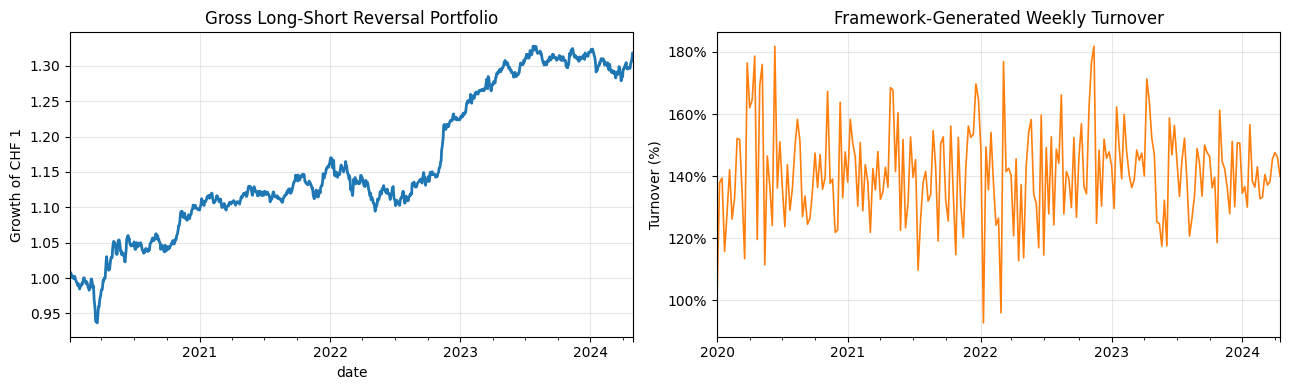

In [11]:
# ---------------------------------------------------------------------------
# Gross out-of-sample evidence for the frozen strategy
# ---------------------------------------------------------------------------
gross_metrics = performance_table(
    ls_gross_returns.to_frame(),
    turnover_map={"Long-Short Gross": ls_combined_turnover},
)
display(gross_metrics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
(1 + ls_gross_returns).cumprod().plot(ax=axes[0], color="C0", linewidth=2.0)
axes[0].set_title("Gross Long-Short Reversal Portfolio")
axes[0].set_ylabel("Growth of CHF 1")
axes[0].grid(True, alpha=0.3)

(100 * ls_combined_turnover).plot(ax=axes[1], color="C1", linewidth=1.2)
axes[1].set_title("Framework-Generated Weekly Turnover")
axes[1].set_ylabel("Turnover (%)")
axes[1].yaxis.set_major_formatter(PercentFormatter())
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


## Transaction-Cost Capacity Analysis

A weekly reversal strategy can require substantial turnover because securities may move rapidly between ranked tails. Gross performance is therefore insufficient to assess economic viability.

Holding the frozen strategy and its framework-generated turnover fixed, one-way transaction costs are applied over the grid

$$
c \in \{0,2,4,6,8,10,12,14,16,18,20\} \text{ basis points}.
$$

For each assumed cost per unit of turnover, net portfolio return is

$$
R^{LS,net}_{t}(c)
=
R^{LS,gross}_{t}
-
\frac{c}{10{,}000}Turnover^{LS}_{t}.
$$

This section is a stress test of implementation capacity. The cost grid is not used to modify the signal, choose a new tail fraction or alter the out-of-sample strategy.

The grid varies **variable trading costs only**. The primary assignment-compliant net result reported below separately applies the required **20 bps** variable cost together with the required **1% annual fixed-cost** drag.

In [12]:
# ---------------------------------------------------------------------------
# Variable transaction-cost stress test using fixed gross returns and turnover
# ---------------------------------------------------------------------------
net_returns_by_cost = {}
for cost_bps in CONFIG.transaction_cost_bps:
    cost_rate = cost_bps / 10_000
    net_returns_by_cost[cost_bps] = subtract_rebalance_costs(
        gross_returns=ls_gross_returns,
        turnover=ls_combined_turnover,
        transaction_cost=cost_rate,
    ).rename(f"{cost_bps} bps")

net_returns_by_cost = pd.DataFrame(net_returns_by_cost).dropna()
cost_capacity_rows = []
for cost_bps in CONFIG.transaction_cost_bps:
    net_returns = net_returns_by_cost[cost_bps]
    cost_capacity_rows.append(
        {
            "Transaction cost (bps)": cost_bps,
            "Annualized net return": (1 + net_returns).prod() ** (CONFIG.trading_days_per_year / len(net_returns)) - 1,
            "Annualized volatility": net_returns.std() * np.sqrt(CONFIG.trading_days_per_year),
            "Net Sharpe ratio": net_returns.mean() / net_returns.std() * np.sqrt(CONFIG.trading_days_per_year),
            "Maximum drawdown": max_drawdown(net_returns),
            "Final cumulative return": (1 + net_returns).prod() - 1,
        }
    )

cost_capacity_table = pd.DataFrame(cost_capacity_rows).set_index("Transaction cost (bps)")
cost_capacity_table.round(4)


,Annualized net return,Annualized volatility,Net Sharpe ratio,Maximum drawdown,Final cumulative return
Transaction cost (bps),,,,,
0,0.0618,0.0532,1.1534,-0.0706,0.3076
2,0.0468,0.0533,0.8850,-0.0733,0.2272
4,0.0321,0.0535,0.6170,-0.0761,0.1517
6,0.0175,0.0537,0.3504,-0.0788,0.0808
8,0.0032,0.0540,0.0859,-0.0953,0.0143
10,-0.0110,0.0544,-0.1756,-0.1142,-0.0481
12,-0.0249,0.0548,-0.4334,-0.1377,-0.1067
14,-0.0387,0.0552,-0.6866,-0.1857,-0.1618
16,-0.0523,0.0558,-0.9348,-0.2311,-0.2134


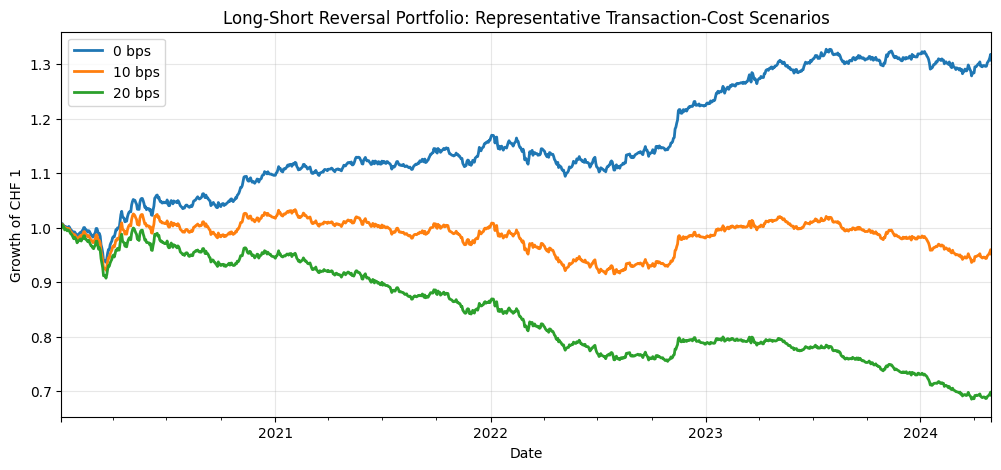

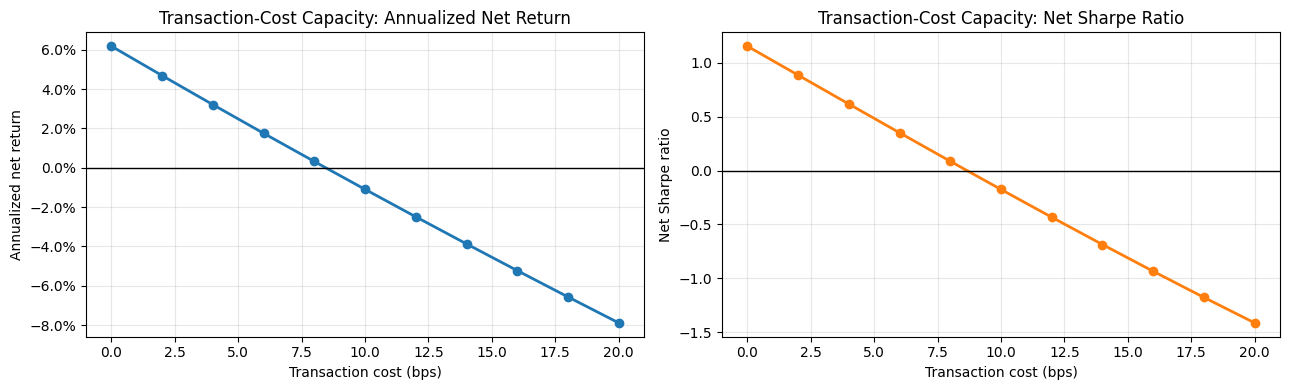

In [13]:
# ---------------------------------------------------------------------------
# Report-quality views of transaction-cost capacity
# ---------------------------------------------------------------------------
representative_costs = [0, 10, 20]
ax = (1 + net_returns_by_cost[representative_costs]).cumprod().plot(
    figsize=(12, 5), linewidth=2.0
)
ax.set_title("Long-Short Reversal Portfolio: Representative Transaction-Cost Scenarios")
ax.set_ylabel("Growth of CHF 1")
ax.set_xlabel("Date")
ax.legend([f"{cost} bps" for cost in representative_costs])
ax.grid(True, alpha=0.3)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cost_capacity_table["Annualized net return"].plot(
    ax=axes[0], marker="o", color="C0", linewidth=2.0
)
axes[0].axhline(0, color="black", linewidth=1.0)
axes[0].set_title("Transaction-Cost Capacity: Annualized Net Return")
axes[0].set_xlabel("Transaction cost (bps)")
axes[0].set_ylabel("Annualized net return")
axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1))
axes[0].grid(True, alpha=0.3)

cost_capacity_table["Net Sharpe ratio"].plot(
    ax=axes[1], marker="o", color="C1", linewidth=2.0
)
axes[1].axhline(0, color="black", linewidth=1.0)
axes[1].set_title("Transaction-Cost Capacity: Net Sharpe Ratio")
axes[1].set_xlabel("Transaction cost (bps)")
axes[1].set_ylabel("Net Sharpe ratio")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


## Assignment-Required Net Long-Short Result

The transaction-cost capacity analysis above varies one-way trading costs to illustrate economic sensitivity. The assignment-compliant net result is reported separately and prominently. It applies both required frictions:

$$
20 \text{ bps per unit of turnover}
\quad + \quad
1\% \text{ annual fixed cost}.
$$

This required-cost series is the primary measure of whether the direct implementation is economically viable for the assignment.

In [14]:
# ---------------------------------------------------------------------------
# Assignment-compliant long-short net return: required variable and fixed cost
# ---------------------------------------------------------------------------
ls_net_required_costs = subtract_rebalance_costs(
    gross_returns=ls_gross_returns,
    turnover=ls_combined_turnover,
    transaction_cost=CONFIG.required_transaction_cost_bps / 10_000,
)
ls_net_required_costs = apply_fixed_cost_drag(
    returns=ls_net_required_costs,
    annual_cost=CONFIG.required_fixed_cost_annual,
).rename("Long-Short Net Required Costs")

performance_table(
    pd.concat([ls_gross_returns, ls_net_required_costs], axis=1),
    turnover_map={
        "Long-Short Gross": ls_combined_turnover,
        "Long-Short Net Required Costs": ls_combined_turnover,
    },
).round(4)


,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown,Final cumulative return,Positive-return-day ratio,Average weekly turnover,Annualized turnover,Return observations
Portfolio,,,,,,,,,
Long-Short Gross,0.0618,0.0532,1.1534,-0.0706,0.3076,0.5129,1.4101,73.3246,1127
Long-Short Net Required Costs,-0.0880,0.0569,-1.5884,-0.3477,-0.3375,0.4401,1.4101,73.3246,1127


## Constrained Black-Litterman Implementation

The direct long-short strategy is the closest representation of the frozen reversal signal, but a weekly top-minus-bottom portfolio may generate substantial turnover. Black-Litterman provides a second implementation layer: the same frozen score is translated into relative return views and combined with a market-cap prior, covariance risk estimates, long-only constraints, concentration limits and turnover control.

This section does not redefine or reselect the signal. It asks whether the selected reversal view can contribute to a practical benchmark-oriented Swiss equity portfolio after assignment-required transaction costs.

### Prior And Views

The framework constructs a market-cap prior and obtains market-implied expected returns:

$$
\mu^{prior}_t = \Sigma_t w^{mkt}_t.
$$

The frozen reversal score determines relative views. Securities with high reversal scores are favored relative to low-score securities. The posterior expected return combines the prior and the views:

$$
\mu^{BL}_t
=
\left(P_t^\top \Omega^{-1}P_t + \Psi^{-1}\right)^{-1}
\left(P_t^\top \Omega^{-1}q_t + \Psi^{-1}\mu^{prior}_t\right).
$$

Here, $\Psi = \tau_{\psi}\Sigma_t$ represents uncertainty about the market-cap prior and $\Omega = \tau_{\omega}I$ represents uncertainty about the reversal views. A larger $\tau_{\psi}$ weakens the prior, whereas a smaller $\tau_{\omega}$ gives more confidence to the reversal view.

The parameterization expresses the implementation design rather than a new parameter search: the selected weekly signal is allowed meaningful influence, single-name allocations are controlled and turnover is capped at 50% per rebalance to preserve responsiveness while limiting trading intensity.

The framework's `longshort_sort` view generator constructs its relative view from top and bottom quintiles of the score distribution. The direct long-short strategy uses 30% tails. Black-Litterman is therefore a constrained implementation of the same ranking signal, not an exact replication of the direct spread.

In [15]:
# ---------------------------------------------------------------------------
# Black-Litterman inputs and practical portfolio constraints
# ---------------------------------------------------------------------------
bl_optimization_builders = {
    "return_series": OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=CONFIG.lookback_days,
        weekdays_only=True,
        fillna_value=0,
    ),
    "cap_weights": OptimizationItemBuilder(bibfn=bibfn_cap_weights),
    "scores": OptimizationItemBuilder(
        bibfn=bibfn_scores,
        fields=["vol_scaled_reversal"],
    ),
    "budget_constraint": OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1,
    ),
    "box_constraints": OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        lower=0,
        upper=CONFIG.stock_upper_bound,
    ),
    # Market-cap-dependent limits prevent a moderate liquidity screen from
    # producing an excessive allocation to the smallest retained securities.
    "size_dependent_upper_bounds": OptimizationItemBuilder(
        bibfn=bibfn_size_dependent_upper_bounds,
        small_cap={"threshold": 300_000_000, "upper": 0.02},
        mid_cap={"threshold": 1_000_000_000, "upper": 0.05},
        large_cap={"threshold": 10_000_000_000, "upper": CONFIG.stock_upper_bound},
    ),
    "turnover_constraint": OptimizationItemBuilder(
        bibfn=bibfn_turnover_constraint,
        turnover_limit=CONFIG.turnover_limit,
    ),
}

bl_optimizer = BlackLitterman(
    covariance=Covariance(method="pearson", check_positive_definite=True),
    tau_psi=CONFIG.tau_psi,
    tau_omega=CONFIG.tau_omega,
    view_gen_algo=CONFIG.view_gen_algo,
    use_unconditional_cov=True,
    signal_names=["vol_scaled_reversal"],
    solver_name=CONFIG.solver_name,
)

bs_bl = BacktestService(
    data=data,
    selection_item_builders=selection_builders,
    optimization_item_builders=bl_optimization_builders,
    optimization=bl_optimizer,
    rebdates=rebalance_dates,
    quiet=False,
)


### Run Black-Litterman Portfolio Formation

The following cell forms the constrained, long-only portfolio through the same professor framework and the same out-of-sample rebalance dates used for the direct strategy.

In [16]:
# Run the constrained Black-Litterman portfolio formation through the framework.
bt_bl = Backtest()
bt_bl.run(bs_bl)


Running backtest: 100%|##########| 225/225 [11:45<00:00,  3.14s/it, 2024-04-19]


## Black-Litterman Returns, Turnover And Required Costs

The Black-Litterman portfolio is simulated gross of costs first to measure its constrained exposure to the frozen signal. The assignment-compliant net result then deducts both 20 bps per unit of realized turnover and the required 1% annual fixed cost.

Implementation diagnostics examine whether this portfolio improves on the direct spread through lower turnover and controlled concentration.

,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown,Final cumulative return,Positive-return-day ratio,Average weekly turnover,Annualized turnover,Return observations
Portfolio,,,,,,,,,
Black-Litterman Gross,0.0217,0.1083,0.2528,-0.2430,0.1008,0.5244,0.0649,3.3728,1127
Black-Litterman Net Required Costs,0.0050,0.1083,0.1006,-0.2449,0.0226,0.5217,0.0649,3.3728,1127


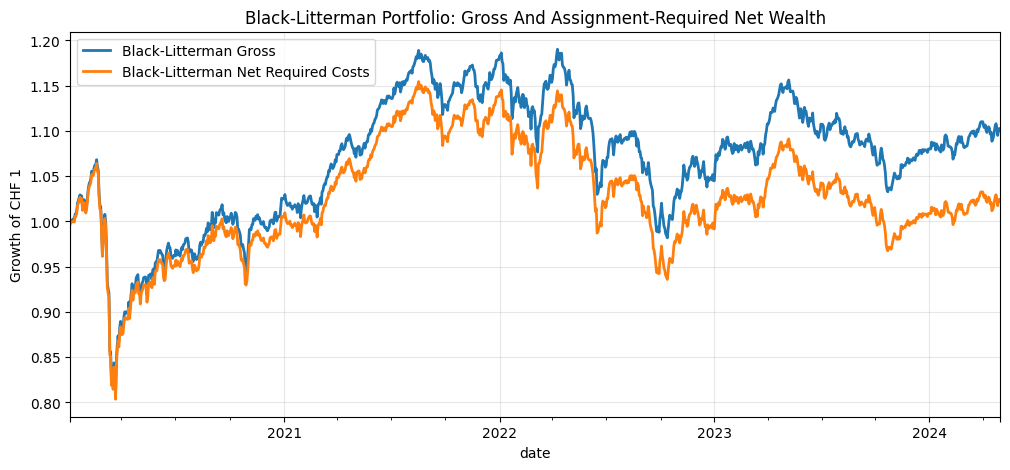

In [17]:
# ---------------------------------------------------------------------------
# Framework-simulated Black-Litterman returns and assignment-required costs
# ---------------------------------------------------------------------------
bl_gross_returns = bt_bl.strategy.simulate(
    return_series=return_series,
    fc=0.0,
    vc=0.0,
).rename("Black-Litterman Gross")
bl_turnover = bt_bl.strategy.turnover(
    return_series=return_series,
    rescale=False,
)
bl_turnover.index = pd.to_datetime(bl_turnover.index)

bl_net_required_costs = subtract_rebalance_costs(
    gross_returns=bl_gross_returns,
    turnover=bl_turnover,
    transaction_cost=CONFIG.required_transaction_cost_bps / 10_000,
)
bl_net_required_costs = apply_fixed_cost_drag(
    returns=bl_net_required_costs,
    annual_cost=CONFIG.required_fixed_cost_annual,
).rename("Black-Litterman Net Required Costs")

bl_required_cost_metrics = performance_table(
    pd.concat([bl_gross_returns, bl_net_required_costs], axis=1),
    turnover_map={
        "Black-Litterman Gross": bl_turnover,
        "Black-Litterman Net Required Costs": bl_turnover,
    },
)
display(bl_required_cost_metrics.round(4))
ax = pd.concat([bl_gross_returns, bl_net_required_costs], axis=1).pipe(lambda x: (1 + x).cumprod()).plot(
    figsize=(12, 5), linewidth=2.0
)
ax.set_title("Black-Litterman Portfolio: Gross And Assignment-Required Net Wealth")
ax.set_ylabel("Growth of CHF 1")
ax.grid(True, alpha=0.3)
plt.show()


## Implementation Diagnostics: Breadth, Concentration And Turnover

Return comparisons alone do not show whether the constrained implementation is more practical. The following diagnostics compare the number of holdings, maximum absolute single-name allocation and realized turnover. For the Black-Litterman portfolio, the final column also reports how frequently realized rebalance turnover is close to the imposed 50% cap.

The initial portfolio formation is excluded from average and maximum rebalance-turnover statistics because it represents initial investment rather than recurring portfolio trading.

In [18]:
# ---------------------------------------------------------------------------
# Portfolio breadth, concentration and recurring-turnover diagnostics
# ---------------------------------------------------------------------------
def strategy_weight_matrix(strategy) -> pd.DataFrame:
    """Convert framework portfolios into a rebalance-date by security panel."""
    return pd.DataFrame(
        {
            pd.Timestamp(portfolio.rebalancing_date): pd.Series(portfolio.weights, dtype=float)
            for portfolio in strategy.portfolios
        }
    ).T.sort_index().fillna(0.0)


long_weights = strategy_weight_matrix(bt_long.strategy)
short_weights = strategy_weight_matrix(bt_short.strategy)
ls_signed_weights = long_weights.mul(CONFIG.long_weight).subtract(
    short_weights.mul(abs(CONFIG.short_weight)), fill_value=0.0
).fillna(0.0)
bl_weights = strategy_weight_matrix(bt_bl.strategy)

# The first turnover observation establishes the initial portfolio rather than
# measuring an ordinary rebalance, so it is excluded from turnover summaries.
ls_rebalance_turnover = ls_combined_turnover.iloc[1:]
bl_rebalance_turnover = bl_turnover.iloc[1:]
implementation_summary = pd.DataFrame(
    {
        "Average holdings": [
            (ls_signed_weights.abs() > 1e-12).sum(axis=1).mean(),
            (bl_weights > 1e-12).sum(axis=1).mean(),
        ],
        "Maximum single-name weight": [
            ls_signed_weights.abs().max().max(),
            bl_weights.max().max(),
        ],
        "Average rebalance turnover": [
            ls_rebalance_turnover.mean(),
            bl_rebalance_turnover.mean(),
        ],
        "Maximum rebalance turnover": [
            ls_rebalance_turnover.max(),
            bl_rebalance_turnover.max(),
        ],
        "Annualized turnover": [
            ls_rebalance_turnover.mean() * CONFIG.rebalances_per_year,
            bl_rebalance_turnover.mean() * CONFIG.rebalances_per_year,
        ],
        "Turnover cap nearly binding": [
            np.nan,
            (bl_rebalance_turnover >= CONFIG.turnover_limit - 0.01).mean(),
        ],
    },
    index=["Direct Long-Short", "Black-Litterman"],
)

implementation_summary.round(4)


,Average holdings,Maximum single-name weight,Average rebalance turnover,Maximum rebalance turnover,Annualized turnover,Turnover cap nearly binding
Direct Long-Short,71.1378,0.0147,1.4119,1.8185,73.4198,NaN
Black-Litterman,49.7200,0.1000,0.0607,0.2729,3.1557,0.0000


## Strategy Comparison: Return, Risk And Implementation Cost

The direct long-short strategy isolates the reversal ranking effect. The Black-Litterman strategy evaluates whether the same signal can be deployed within a fully invested, constrained Swiss equity portfolio. Gross returns describe signal capture before frictions; assignment-compliant net returns are the primary implementation results.

The SPI is included as the invested Swiss equity benchmark. It is directly comparable to the long-only Black-Litterman portfolio; for the market-neutral long-short spread it provides market context rather than an equal-exposure performance target.

C:\Users\axeli\AppData\Local\Temp\ipykernel_39388\2837888995.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  comparison_returns = pd.concat(


,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown,Final cumulative return,Positive-return-day ratio,Average weekly turnover,Annualized turnover,Return observations
Portfolio,,,,,,,,,
Long-Short Gross,0.0618,0.0532,1.1534,-0.0706,0.3076,0.5129,1.4101,73.3246,1127
Long-Short Net Required Costs,-0.0880,0.0569,-1.5884,-0.3477,-0.3375,0.4401,1.4101,73.3246,1127
Black-Litterman Gross,0.0217,0.1083,0.2528,-0.2430,0.1008,0.5244,0.0649,3.3728,1127
Black-Litterman Net Required Costs,0.0050,0.1083,0.1006,-0.2449,0.0226,0.5217,0.0649,3.3728,1127
SPI,0.0246,0.1290,0.2534,-0.2633,0.1645,0.3716,NaN,NaN,1577


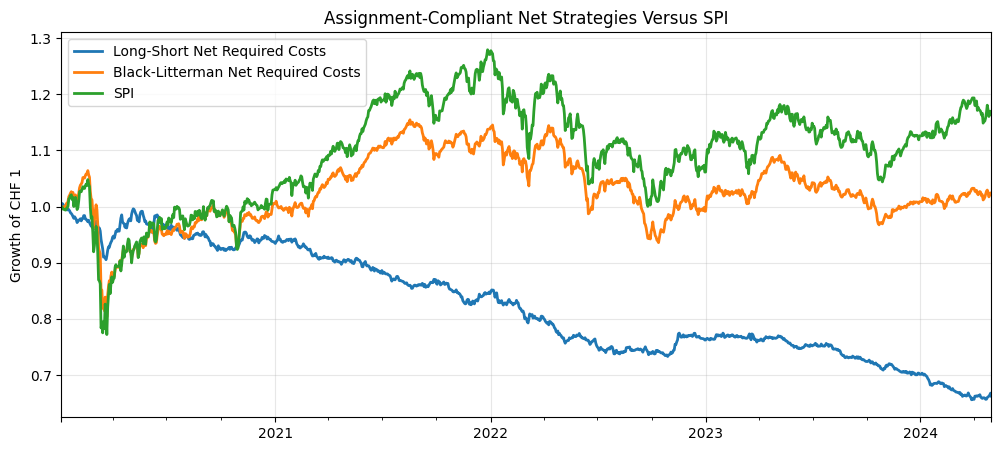

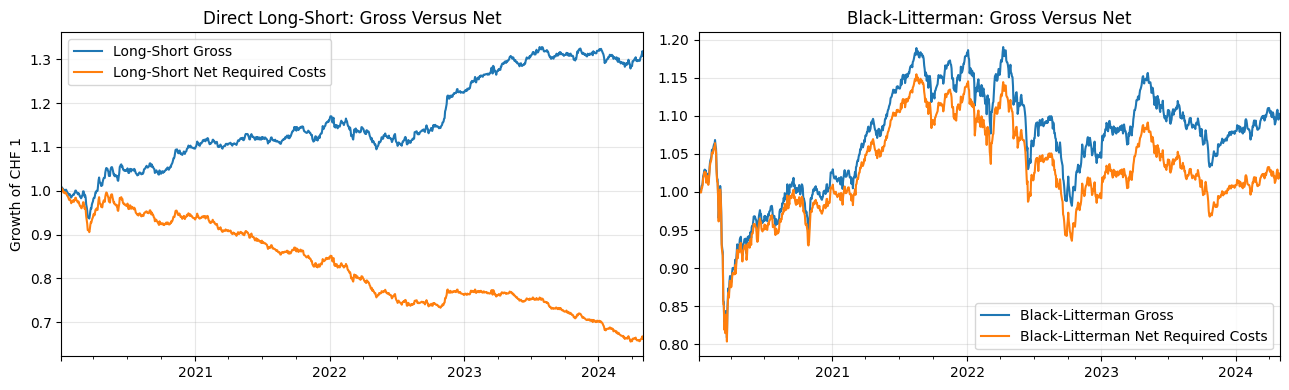

In [19]:
# ---------------------------------------------------------------------------
# Full-period return and risk comparison
# ---------------------------------------------------------------------------
comparison_returns = pd.concat(
    {
        "Long-Short Gross": ls_gross_returns,
        "Long-Short Net Required Costs": ls_net_required_costs,
        "Black-Litterman Gross": bl_gross_returns,
        "Black-Litterman Net Required Costs": bl_net_required_costs,
        "SPI": spi,
    },
    axis=1,
).loc[ls_gross_returns.index.min():ls_gross_returns.index.max()]

comparison_metrics = performance_table(
    comparison_returns,
    turnover_map={
        "Long-Short Gross": ls_combined_turnover,
        "Long-Short Net Required Costs": ls_combined_turnover,
        "Black-Litterman Gross": bl_turnover,
        "Black-Litterman Net Required Costs": bl_turnover,
    },
)
display(comparison_metrics.round(4))

net_comparison = comparison_returns[
    ["Long-Short Net Required Costs", "Black-Litterman Net Required Costs", "SPI"]
].dropna()
ax = (1 + net_comparison).cumprod().plot(figsize=(12, 5), linewidth=2.0)
ax.set_title("Assignment-Compliant Net Strategies Versus SPI")
ax.set_ylabel("Growth of CHF 1")
ax.grid(True, alpha=0.3)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
(1 + comparison_returns[["Long-Short Gross", "Long-Short Net Required Costs"]].dropna()).cumprod().plot(ax=axes[0])
axes[0].set_title("Direct Long-Short: Gross Versus Net")
axes[0].set_ylabel("Growth of CHF 1")
axes[0].grid(True, alpha=0.3)
(1 + comparison_returns[["Black-Litterman Gross", "Black-Litterman Net Required Costs"]].dropna()).cumprod().plot(ax=axes[1])
axes[1].set_title("Black-Litterman: Gross Versus Net")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## SPI-Relative Evaluation Of The Invested Portfolio

The long-short spread is market-neutral and is not designed to match the exposure of a fully invested equity benchmark. By contrast, the Black-Litterman portfolio is long-only and fully invested, making the SPI its natural direct benchmark.

For the Black-Litterman implementation, active return and tracking error are

$$
R^{active}_t = R^{BL}_t - R^{SPI}_t,
\qquad
TE = Std(R^{active}_t)\sqrt{252},
$$

and the SPI-relative information ratio is

$$
IR_{SPI}
=
\frac{\overline{R}^{active}_t}{Std(R^{active}_t)}\sqrt{252}.
$$

In [20]:
# ---------------------------------------------------------------------------
# Benchmark-relative statistics for the fully invested BL portfolio
# ---------------------------------------------------------------------------
spi_relative_rows = []
for name in ["Black-Litterman Gross", "Black-Litterman Net Required Costs"]:
    aligned = comparison_returns[[name, "SPI"]].dropna()
    active = aligned[name] - aligned["SPI"]
    beta = aligned[name].cov(aligned["SPI"]) / aligned["SPI"].var()
    alpha_daily = aligned[name].mean() - beta * aligned["SPI"].mean()
    spi_relative_rows.append(
        {
            "Portfolio": name,
            "Annualized active return": active.mean() * CONFIG.trading_days_per_year,
            "Tracking error": active.std() * np.sqrt(CONFIG.trading_days_per_year),
            "SPI information ratio": active.mean() / active.std() * np.sqrt(CONFIG.trading_days_per_year),
            "Market beta": beta,
            "Annualized market alpha": alpha_daily * CONFIG.trading_days_per_year,
            "Observations": len(aligned),
        }
    )

spi_relative_results = pd.DataFrame(spi_relative_rows).set_index("Portfolio")
spi_relative_results.round(4)


,Annualized active return,Tracking error,SPI information ratio,Market beta,Annualized market alpha,Observations
Portfolio,,,,,,
Black-Litterman Gross,-0.0184,0.0637,-0.2886,0.6646,-0.0030,1127
Black-Litterman Net Required Costs,-0.0349,0.0637,-0.5476,0.6648,-0.0195,1127


## Multifactor Benchmark Analysis

A multifactor benchmark distinguishes performance driven by broad style exposures from performance specific to this portfolio implementation. Two models are reported for the assignment-compliant net strategies.

### Broad Style Benchmark

$$
R_{p,t} = \alpha_p + \beta_{SPI,p}SPI_t + \beta_{MOM,p}Momentum_t + \beta_{LR,p}LowRisk_t + \beta_{SIZE,p}Size_t + \varepsilon_{p,t}.
$$

This specification asks whether the strategies earn alpha beyond broad Swiss market and style exposures.

### Reversal-Controlled Benchmark

$$
R_{p,t} = \alpha_p + \beta_{SPI,p}SPI_t + \beta_{MOM,p}Momentum_t + \beta_{LR,p}LowRisk_t + \beta_{SIZE,p}Size_t + \beta_{STR,p}ShortTermReversal_t + \varepsilon_{p,t}.
$$

This specification asks whether the implementation adds performance beyond a generic short-term reversal factor. Since the out-of-sample interval is relatively short, alpha inference is interpreted cautiously.

The appraisal ratio is defined as annualized alpha divided by annualized residual volatility; it measures factor-adjusted alpha per unit of residual risk.

In [21]:
# ---------------------------------------------------------------------------
# Swiss equity factor benchmark inputs
# ---------------------------------------------------------------------------
factor_raw = pd.read_csv(CONFIG.data_dir / "jkp_factor_series_che_eqw.csv")
factor_raw["date"] = pd.to_datetime(factor_raw["date"], dayfirst=True)
factor_returns = (
    factor_raw.pivot_table(index="date", columns="name", values="ret", aggfunc="last")
    .sort_index()
    .join(spi.rename("SPI"), how="outer")
)

requested_factor_models = {
    "Broad Style": ["SPI", "momentum", "low_risk", "size"],
    "Reversal-Controlled": ["SPI", "momentum", "low_risk", "size", "short_term_reversal"],
}
factor_models = {
    model: [factor for factor in factors if factor in factor_returns.columns]
    for model, factors in requested_factor_models.items()
}

pd.DataFrame({"Factors used": factor_models}).T


,Broad Style,Reversal-Controlled
Factors used,"[SPI, momentum, low_risk, size]","[SPI, momentum, low_risk, size, short_term_rev..."


In [22]:
# ---------------------------------------------------------------------------
# One concise OLS helper for factor-adjusted performance attribution
# ---------------------------------------------------------------------------
def factor_regression(
    strategy_returns: pd.Series,
    factor_returns: pd.DataFrame,
    factor_columns: list[str],
    periods_per_year: int = 252,
) -> tuple[pd.Series, pd.Series]:
    """Estimate annualized alpha, inference and factor exposures for one strategy."""
    regression_data = pd.concat(
        [strategy_returns.rename("strategy"), factor_returns[factor_columns]], axis=1
    ).replace([np.inf, -np.inf], np.nan).dropna()

    y = regression_data["strategy"].to_numpy(dtype=float)
    x = regression_data[factor_columns].to_numpy(dtype=float)
    design = np.column_stack([np.ones(len(x)), x])
    params = np.linalg.pinv(design.T @ design) @ design.T @ y
    residuals = y - design @ params

    degrees_of_freedom = max(len(y) - design.shape[1], 1)
    error_variance = residuals.T @ residuals / degrees_of_freedom
    parameter_covariance = error_variance * np.linalg.pinv(design.T @ design)
    alpha_daily = params[0]
    alpha_standard_error = np.sqrt(parameter_covariance[0, 0])
    residual_volatility = residuals.std(ddof=1) * np.sqrt(periods_per_year)
    annualized_alpha = alpha_daily * periods_per_year

    total_variation = ((y - y.mean()) ** 2).sum()
    residual_variation = (residuals ** 2).sum()
    r_squared = 1 - residual_variation / total_variation if total_variation > 0 else np.nan
    summary = pd.Series(
        {
            "Annualized Alpha": annualized_alpha,
            "Alpha t-Stat": alpha_daily / alpha_standard_error if alpha_standard_error > 0 else np.nan,
            "Appraisal Ratio": annualized_alpha / residual_volatility if residual_volatility > 0 else np.nan,
            "R-Squared": r_squared,
            "Residual Volatility": residual_volatility,
            "Observations": len(regression_data),
        }
    )
    betas = pd.Series(params[1:], index=factor_columns, dtype=float)
    return summary, betas


# Primary attribution is performed on assignment-compliant net results.
factor_test_portfolios = {
    "Long-Short Net Required Costs": ls_net_required_costs,
    "Black-Litterman Net Required Costs": bl_net_required_costs,
}
factor_summaries = []
factor_exposures = []
for portfolio_name, portfolio_returns in factor_test_portfolios.items():
    for model_name, factor_columns in factor_models.items():
        summary, betas = factor_regression(portfolio_returns, factor_returns, factor_columns)
        factor_summaries.append({"Portfolio": portfolio_name, "Model": model_name, **summary.to_dict()})
        factor_exposures.append({"Portfolio": portfolio_name, "Model": model_name, **betas.to_dict()})

factor_alpha_summary = pd.DataFrame(factor_summaries).set_index(["Portfolio", "Model"])
factor_beta_table = pd.DataFrame(factor_exposures).set_index(["Portfolio", "Model"])
display(factor_alpha_summary.round(4))
factor_beta_table.xs("Reversal-Controlled", level="Model").round(4)


C:\Users\axeli\AppData\Local\Temp\ipykernel_39388\3624173878.py:11: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  regression_data = pd.concat(
C:\Users\axeli\AppData\Local\Temp\ipykernel_39388\3624173878.py:11: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  regression_data = pd.concat(
C:\Users\axeli\AppData\Local\Temp\ipykernel_39388\3624173878.py:11: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sor

Annualized Alpha  \
Portfolio                          Model                                   
Long-Short Net Required Costs      Broad Style                   -0.0915   
                                   Reversal-Controlled           -0.0939   
Black-Litterman Net Required Costs Broad Style                   -0.0240   
                                   Reversal-Controlled           -0.0242   

                                                        Alpha t-Stat  \
Portfolio                          Model                               
Long-Short Net Required Costs      Broad Style               -3.3626   
                                   Reversal-Controlled       -3.4905   
Black-Litterman Net Required Costs Broad Style               -1.3370   
                                   Reversal-Controlled       -1.3459   

                                                        Appraisal Ratio  \
Portfolio                          Model                                  
Long-Short Net Required Costs      Broad Style                  -1.6219   
                                   Reversal-Controlled          -1.6846   
Black-Litterman Net Required Costs Broad Style                  -0.6449   
                                   Reversal-Controlled          -0.6496   

                                                        R-Squared  \
Portfolio                          Model                            
Long-Short Net Required Costs      Broad Style             0.0436   
                                   Reversal-Controlled     0.0663   
Black-Litterman Net Required Costs Broad Style             0.8855   
                                   Reversal-Controlled     0.8856   

                                                        Residual Volatility  \
Portfolio                          Model                                      
Long-Short Net Required Costs      Broad Style                       0.0564   
                                   Reversal-Controlled               0.0557   
Black-Litterman Net Required Costs Broad Style                       0.0372   
                                   Reversal-Controlled               0.0372   

                                                        Observations  
Portfolio                          Model                              
Long-Short Net Required Costs      Broad Style            1,093.0000  
                                   Reversal-Controlled    1,093.0000  
Black-Litterman Net Required Costs Broad Style            1,093.0000  
                                   Reversal-Controlled    1,093.0000

,SPI,momentum,low_risk,size,short_term_reversal
Portfolio,,,,,
Long-Short Net Required Costs,0.0391,0.0742,-0.0971,0.0381,0.1407
Black-Litterman Net Required Costs,0.7399,-0.0137,0.1158,0.0893,0.0101


## Subperiod Stability During The Evaluation Window

Because the out-of-sample period is relatively short, the analysis uses only two economically interpretable subperiods rather than repeatedly splitting the data:

- `2020-2021`: pandemic shock and recovery environment;
- `2022-2024`: inflation and interest-rate normalization environment.

These subperiods are descriptive checks, not new model-selection samples. Factor regressions are intentionally reported only for the full evaluation interval.

In [23]:
# ---------------------------------------------------------------------------
# Descriptive subperiod comparison for required-net strategies and benchmark
# ---------------------------------------------------------------------------
subperiods = {
    "2020-2021": ("2020-01-01", "2021-12-31"),
    "2022-2024": ("2022-01-01", "2024-12-31"),
}
subperiod_returns = comparison_returns[
    ["Long-Short Net Required Costs", "Black-Litterman Net Required Costs", "SPI"]
]
subperiod_rows = []
for period_name, (start, end) in subperiods.items():
    metrics = performance_table(subperiod_returns.loc[start:end])
    metrics["Subperiod"] = period_name
    subperiod_rows.append(metrics.reset_index())

subperiod_table = pd.concat(subperiod_rows, ignore_index=True).set_index(["Subperiod", "Portfolio"])
subperiod_table[
    ["Annualized return", "Annualized volatility", "Sharpe ratio", "Maximum drawdown", "Return observations"]
].round(4)


Annualized return  \
Subperiod Portfolio                                               
2020-2021 Long-Short Net Required Costs                 -0.0783   
          Black-Litterman Net Required Costs             0.0647   
          SPI                                            0.0868   
2022-2024 Long-Short Net Required Costs                 -0.0961   
          Black-Litterman Net Required Costs            -0.0434   
          SPI                                           -0.0256   

                                              Annualized volatility  \
Subperiod Portfolio                                                   
2020-2021 Long-Short Net Required Costs                      0.0609   
          Black-Litterman Net Required Costs                 0.1243   
          SPI                                                0.1464   
2022-2024 Long-Short Net Required Costs                      0.0533   
          Black-Litterman Net Required Costs                 0.0924   
          SPI                                                0.1121   

                                              Sharpe ratio  Maximum drawdown  \
Subperiod Portfolio                                                            
2020-2021 Long-Short Net Required Costs            -1.3083           -0.1794   
          Black-Litterman Net Required Costs        0.5670           -0.2449   
          SPI                                       0.6425           -0.2633   
2022-2024 Long-Short Net Required Costs            -1.8680           -0.2297   
          Black-Litterman Net Required Costs       -0.4344           -0.1828   
          SPI                                      -0.1751           -0.2170   

                                              Return observations  
Subperiod Portfolio                                                
2020-2021 Long-Short Net Required Costs                       520  
          Black-Litterman Net Required Costs                  520  
          SPI                                                 726  
2022-2024 Long-Short Net Required Costs                       607  
          Black-Litterman Net Required Costs                  607  
          SPI                                                 851

## Final Interpretation

This section will be completed after execution of the updated notebook. The final interpretation will answer four questions:

1. Does the frozen volatility-scaled reversal signal retain positive out-of-sample performance in the transparent long-short implementation?
2. Does that direct implementation remain viable under the assignment-required 20 bps transaction cost and 1% annual fixed cost?
3. Does the Black-Litterman portfolio reduce turnover and concentration while retaining economically meaningful exposure to the reversal signal?
4. Do SPI-relative and multifactor results indicate performance beyond broad market/style exposures, and does any alpha remain after controlling for a generic short-term reversal factor?

The signal definition remains frozen throughout the evaluation. Differences between the two implementations are attributed to portfolio construction, constraints, turnover and implementation costs rather than to a new alpha search.